In [1]:
import sys
import os
import pandas as pd

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dgp import GaussianNetwork
from src.methods import RVPermutationTest
from src.helper_functions.simulation_functions import run_simulation
from src.helper_functions.analyse_functions import aggregate_results
import re
from src.helper_functions.plot_functions import plot_grid, plot_with_bands, plot_scatter_markers
import ast
import numpy as np
from functools import partial

In [2]:
import matplotlib.pyplot as plt


rcparams = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 9,
    "figure.titlesize": 11,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10.5,
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
}

plt.rcParams.update(rcparams)

In [3]:
color_map = {
    'DistanceCorrelation': '#4285F4', # Blue
    'ObservedCVM': '#EA4335', # Red
    'QAP': '#38761D',  # Dark Green
    'RVPermutationTest': '#FBBC05'  # Yellow
}

marker_map = {
    'DistanceCorrelation': 'x',
    'ObservedCVM': 'o',
    'QAP': 'D',
    'RVPermutationTest': 'v'
}

In [4]:
results1 = pd.read_csv("sim_lee2019_20260326_1409.csv")

In [5]:
results_concat = results1.copy()

In [6]:
import re

def parse_config_string(s):
    # 1. Extract rough key-value pairs
    pairs = dict(re.findall(r"'([^']+)':\s*([^,}]+)", s))

    # 2. NEW: Extract latent_sim specifically
    # Look for latent_sim='...' or latent_sim="..."
    ls_match = re.search(r"latent_sim=['\"]([^'\"]+)['\"]", s)
    pairs['latent_sim'] = ls_match.group(1) if ls_match else "NA"

    # 3. Extract method class specifically from the 'method' field
    method_val_match = re.search(r"'method':\s*(.*?)(?=,\s*'[^']+':|$|})", s, re.DOTALL)
    method_class, test_function = None, None

    if method_val_match:
        method_val = method_val_match.group(1)
        cm = re.search(r"<class '([^']+)'>", method_val)
        if cm:
            method_class = cm.group(1).split('.')[-1]
        fm = re.search(r"test_function=<function ([^ ]+)", method_val)
        if fm:
            test_function = fm.group(1)

    if method_class == "PermutationTest" and test_function:
        method = f"{method_class}_{test_function}"
    else:
        method = method_class
    pairs["method"] = method

    # 4. Extract solver
    solver_match = re.search(r"'solver':\s*<function ([^ ]+)", s)
    if solver_match:
        pairs["solver"] = solver_match.group(1)

    # 5. Clean up np.int64/np.float64 wrappers
    for k, v in pairs.items():
        nm = re.match(r"np\.\w+\(([^)]+)\)", str(v).strip())
        if nm:
            pairs[k] = nm.group(1)
    
    # 6. Extract degree 
    pairs['degree'] = re.search(r"degree=(\d+)", s).group(1) if re.search(r"degree=(\d+)", s) else "NA"

    return pairs

In [7]:
def parse_result_string(s):
    # remove numpy scalar wrappers
    s_clean = re.sub(r"np\.float64\((.*?)\)", r"\1", s)

    return ast.literal_eval(s_clean)

In [8]:
results = results_concat.copy()
results['args'] = results['args'].apply(parse_config_string)

In [9]:
results['ComputeAll'] = results['ComputeAll'].apply(parse_result_string)

In [10]:
results["edge_var"] = results["args"].apply(lambda x: x.get("edge_var", "NA"))
results['n'] = results['args'].apply(lambda x: x.get("n", "NA"))
results['k'] = results['args'].apply(lambda x: x.get("k", "NA"))
results['method'] = results['args'].apply(lambda x: x.get("method", "NA").strip("'"))
results['solver'] = results['args'].apply(lambda x: x.get("solver", "NA").strip("'"))
results['copula'] = results['args'].apply(lambda x: x.get("copula_type", "NA").strip("'"))
results['dgp_name'] = results['args'].apply(lambda x: x.get("dgp_name", "NA").strip("'"))
results['marginals'] = results['args'].apply(lambda x: x.get("marginals", "NA").strip("'"))
results['rho'] = results['args'].apply(lambda x: x.get("rho", "NA").replace('np.float64(', '').replace(')', ''))
results['rho'] = results['rho'].apply(lambda x: float(x))
results['degree'] = results['args'].apply(lambda x: x.get("degree", "NA").replace('np.int64(', '').replace(')', ''))
results['latent_sim'] = results['args'].apply(lambda x: x.get("latent_sim", "NA").strip("'"))

In [11]:
results['n'] = results['n'].apply(lambda x: int(x.replace('np.int64(', '').replace(')', '')))
results['k'] = results['k'].apply(lambda x: int(x.replace('np.int64(', '').replace(')', '')))

In [12]:
results_all = results.copy()

In [13]:
results_all["dgp"] = results_all["args"].apply(lambda x: x.get("dgp_name", "NA"))
results_all['dgp_name'] =  [x.split('_')[0].strip("'") for x in results_all['dgp']]
results_all['copula'] =  [x.split('_')[1].strip("'") for x in results_all['dgp']]

In [14]:
results_all["RelativeFrobeniusNorm_x"] = results_all["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_x", np.nan)
)
results_all["RelativeFrobeniusNorm_z"] = results_all["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_z", np.nan)
)
results_all["FalseRejection"] = results_all["ComputeAll"].apply(lambda x: x["FalseRejection"])
results_all["TrueRejection"] = results_all["ComputeAll"].apply(lambda x: x["TrueRejection"])
results_all["Rejection"] = results_all["ComputeAll"].apply(lambda x: x["Rejection"])

In [15]:
results_all['avg_rel_frob_x'] = (
    results_all
    .groupby(['n', 'method', 'marginals', 'copula', 'dgp_name'])['RelativeFrobeniusNorm_x']
    .transform('mean')
)

In [16]:
results_all['permutation_type'] = results_all['RelativeFrobeniusNorm_x'].apply(lambda x: 'observed' if np.isnan(x) else 'latent')
results_all['method'] = results_all['method'].replace({'DiffusionCorrelation':'DistanceCorrelation'})
results_all.rename(columns={'TrueRejection': 'Power'}, inplace=True)

In [17]:
results_all['latent_sim'] = results_all['latent_sim'].replace({'multiplicative_noise':'mult_noise', 
                                                               'logarithmic':'logarithmic', 
                                                               'uncorrelated_bernoulli':'bernoulli',
                                                               'joint_normal':'normal',
                                                               'exponential':'exponential',
                                                               'w_shaped':'w_shaped'})

In [18]:
results_all['edge_var'].value_counts()

edge_var
1    54400
3    54400
Name: count, dtype: int64

In [19]:
results_all = results_all[results_all['edge_var']=='3']

### Defining different aggregations

In [20]:
# based on dgp
results_gaussian = results_all[(results_all["dgp_name"] == "GaussianNetwork")].copy()
results_bernoulli = results_all[(results_all["dgp_name"] == "BernoulliNetwork")].copy()

In [21]:
# based on rho + dgp
results_null_gaussian = results_gaussian[(results_gaussian["rho"] == 0.0)].copy()
results_alt_05_gaussian = results_gaussian[(results_gaussian["rho"] == 0.5)].copy()
results_alt_02_gaussian = results_gaussian[(results_gaussian["rho"] == 0.2)].copy()

results_null_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.0)].copy()
results_alt_05_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.5)].copy()
results_alt_02_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.2)].copy()

### Power

In [22]:
agg_alt_02_gaussian = aggregate_results(
    results_alt_02_gaussian,
    y_axis="Power",
    x_axis="n",
    factors=["marginals", "method", "latent_sim"]
)
agg_alt_02_bernoulli = aggregate_results(
    results_alt_02_bernoulli,
    y_axis="Power",
    x_axis="n",
    factors=["marginals", "method", "latent_sim"]
)

agg_alt_02_gaussian_frob = aggregate_results(
    results_alt_02_gaussian,
    y_axis="Power",
    x_axis="avg_rel_frob_x",
    factors=["n", "method", "latent_sim"]
)

agg_alt_02_bernoulli_frob = aggregate_results(
    results_alt_02_bernoulli,
    y_axis="Power",
    x_axis="avg_rel_frob_x",
    factors=["n", "method", "latent_sim"]
)

In [23]:
# different params for power plot

rcparams = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
}

plt.rcParams.update(rcparams)

In [24]:
import seaborn as sns
sns.set_context("talk", font_scale=1)

# 2. Update with your specific stylistic overrides
custom_params = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
}
plt.rcParams.update(custom_params)

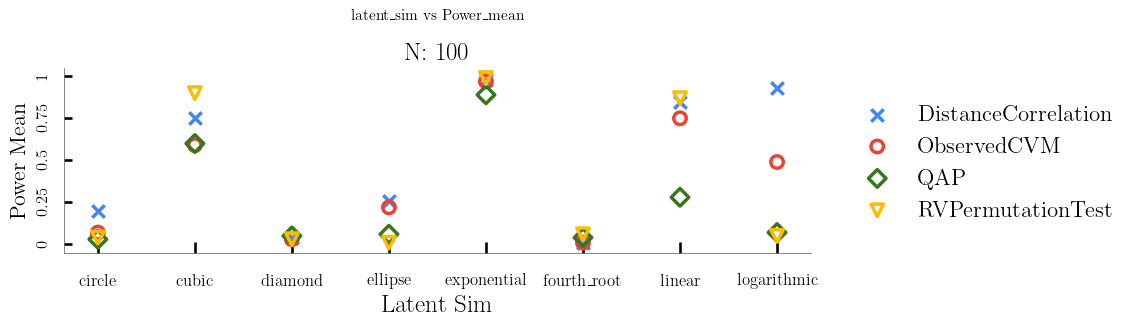

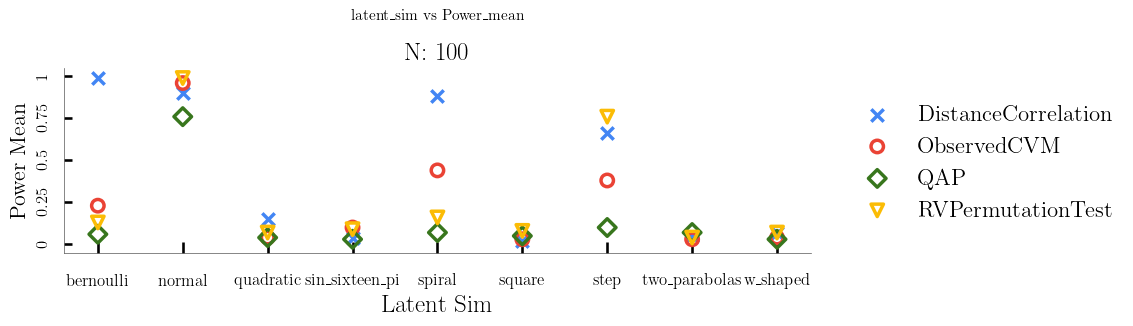

In [25]:
temp = agg_alt_02_gaussian.copy()
temp = temp[temp['n']==100]

first_batch = ['linear', 'circle', 'cubic', 'diamond', 'ellipse', 'exponential', 'fourth_root', 'logarithmic']

plot_grid(
    grouped_stats=temp[temp['latent_sim'].isin(first_batch)],
    x_axis='latent_sim',
    y_axis='Power_mean',
    factors=['method', 'n'],      
    plotting_function=plot_scatter_markers,
    colors=color_map,
    markers=marker_map,
    height=3, 
    aspect=3,
    add_legend=True,
)


plot_grid(
    grouped_stats=temp[~temp['latent_sim'].isin(first_batch)],
    x_axis='latent_sim',
    y_axis='Power_mean',
    factors=['method', 'n'],      
    plotting_function=plot_scatter_markers,
    colors=color_map,
    markers=marker_map,
    height=3, 
    aspect=3,
    add_legend=True,
)

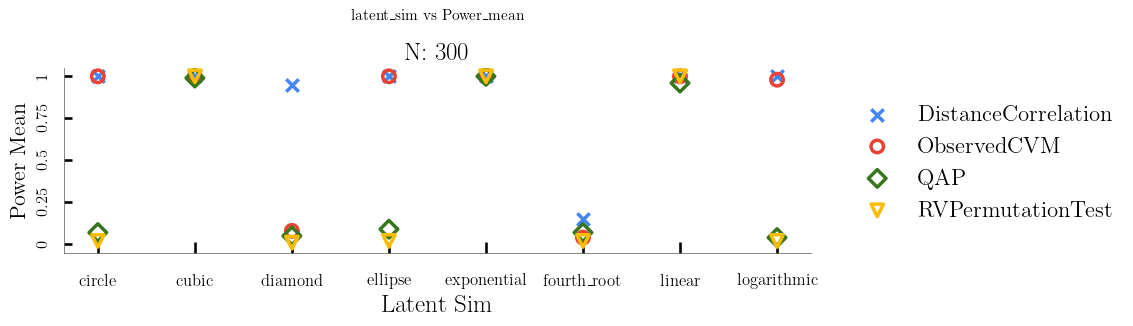

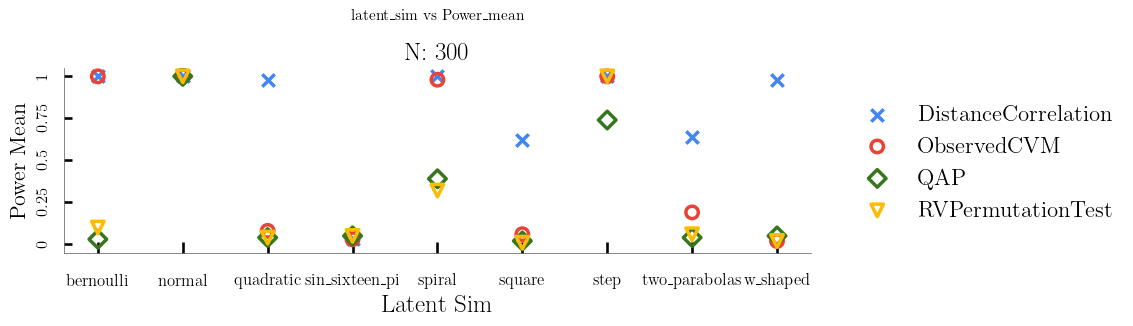

In [26]:
temp = agg_alt_02_gaussian.copy()
temp = temp[temp['n']==300]

first_batch = ['linear', 'circle', 'cubic', 'diamond', 'ellipse', 'exponential', 'fourth_root', 'logarithmic']

plot_grid(
    grouped_stats=temp[temp['latent_sim'].isin(first_batch)],
    x_axis='latent_sim',
    y_axis='Power_mean',
    factors=['method', 'n'],      
    plotting_function=plot_scatter_markers,
    colors=color_map,
    markers=marker_map,
    height=3, 
    aspect=3,
    add_legend=True,
)


plot_grid(
    grouped_stats=temp[~temp['latent_sim'].isin(first_batch)],
    x_axis='latent_sim',
    y_axis='Power_mean',
    factors=['method', 'n'],      
    plotting_function=plot_scatter_markers,
    colors=color_map,
    markers=marker_map,
    height=3, 
    aspect=3,
    add_legend=True,
)

### Binary network

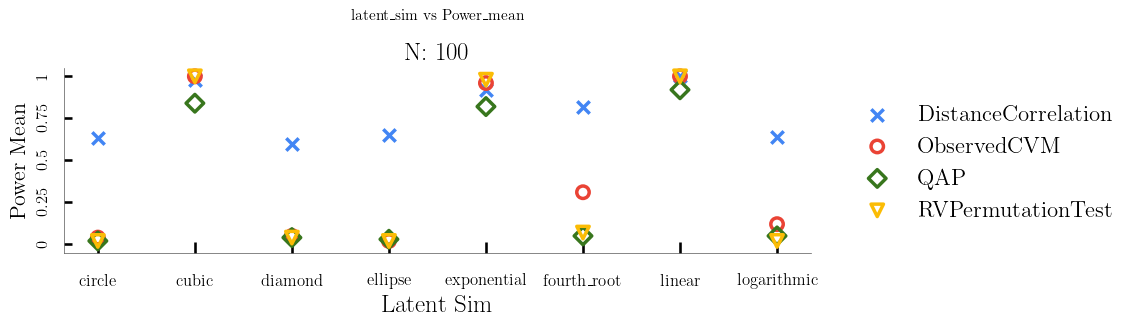

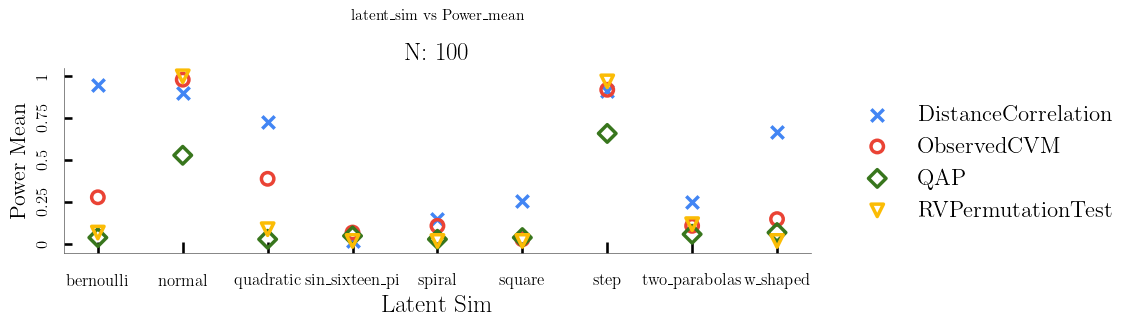

In [27]:
temp = agg_alt_02_bernoulli.copy()
temp = temp[temp['n']==100]

first_batch = ['linear', 'circle', 'cubic', 'diamond', 'ellipse', 'exponential', 'fourth_root', 'logarithmic']

plot_grid(
    grouped_stats=temp[temp['latent_sim'].isin(first_batch)],
    x_axis='latent_sim',
    y_axis='Power_mean',
    factors=['method', 'n'],      
    plotting_function=plot_scatter_markers,
    colors=color_map,
    markers=marker_map,
    height=3, 
    aspect=3,
    add_legend=True,
)


plot_grid(
    grouped_stats=temp[~temp['latent_sim'].isin(first_batch)],
    x_axis='latent_sim',
    y_axis='Power_mean',
    factors=['method', 'n'],      
    plotting_function=plot_scatter_markers,
    colors=color_map,
    markers=marker_map,
    height=3, 
    aspect=3,
    add_legend=True,
)


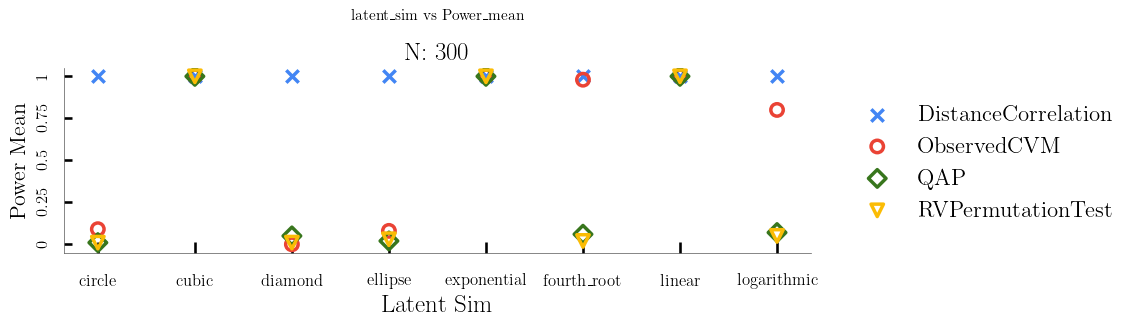

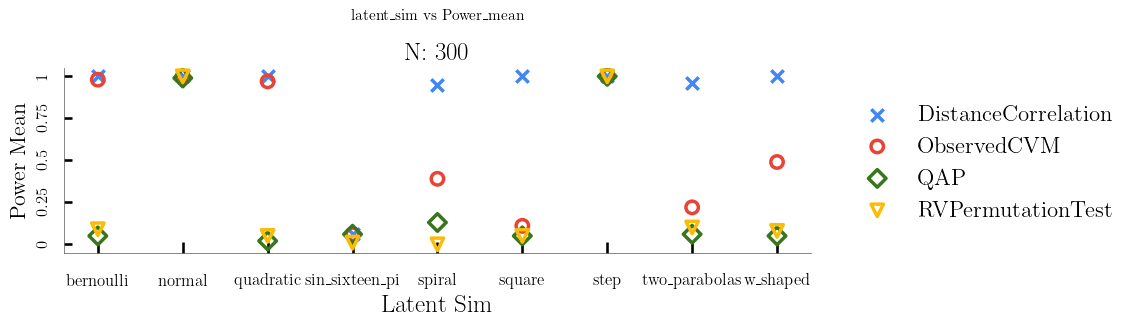

In [28]:
temp = agg_alt_02_bernoulli.copy()
temp = temp[temp['n']==300]

first_batch = ['linear', 'circle', 'cubic', 'diamond', 'ellipse', 'exponential', 'fourth_root', 'logarithmic']

plot_grid(
    grouped_stats=temp[temp['latent_sim'].isin(first_batch)],
    x_axis='latent_sim',
    y_axis='Power_mean',
    factors=['method', 'n'],      
    plotting_function=plot_scatter_markers,
    colors=color_map,
    markers=marker_map,
    height=3, 
    aspect=3,
    add_legend=True,
)


plot_grid(
    grouped_stats=temp[~temp['latent_sim'].isin(first_batch)],
    x_axis='latent_sim',
    y_axis='Power_mean',
    factors=['method', 'n'],      
    plotting_function=plot_scatter_markers,
    colors=color_map,
    markers=marker_map,
    height=3, 
    aspect=3,
    add_legend=True,
)

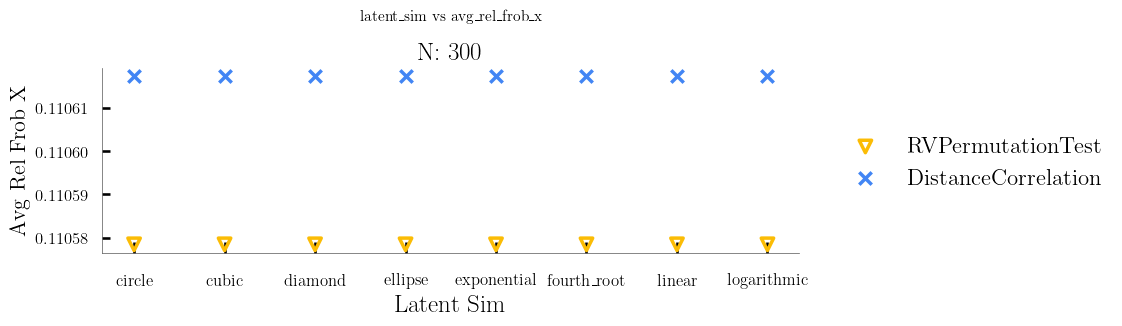

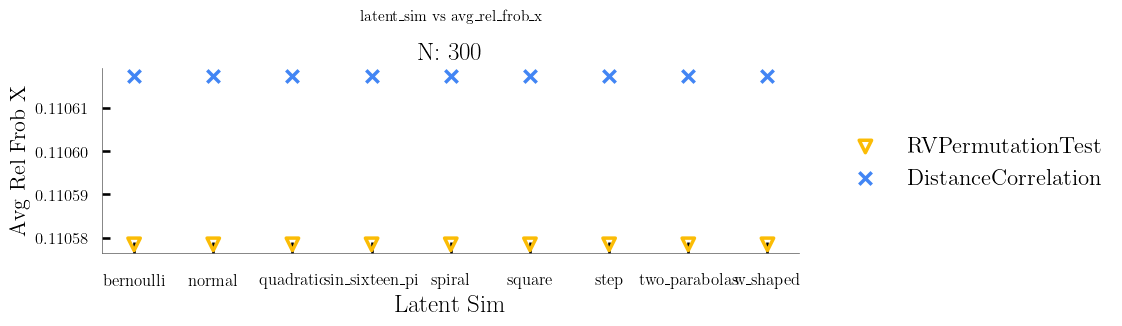

In [29]:
temp = agg_alt_02_bernoulli_frob.copy()
temp = temp[temp['n']==300]

first_batch = ['linear', 'circle', 'cubic', 'diamond', 'ellipse', 'exponential', 'fourth_root', 'logarithmic']

plot_grid(
    grouped_stats=temp[temp['latent_sim'].isin(first_batch)],
    x_axis='latent_sim',
    y_axis='avg_rel_frob_x',
    factors=['method', 'n'],      
    plotting_function=plot_scatter_markers,
    colors=color_map,
    markers=marker_map,
    height=3, 
    aspect=3,
    add_legend=True,
)


plot_grid(
    grouped_stats=temp[~temp['latent_sim'].isin(first_batch)],
    x_axis='latent_sim',
    y_axis='avg_rel_frob_x',
    factors=['method', 'n'],      
    plotting_function=plot_scatter_markers,
    colors=color_map,
    markers=marker_map,
    height=3, 
    aspect=3,
    add_legend=True,
)